In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.fit import *

from pmt.fit.poisson import fit_poisson_spe, poisson_npe_fractions
from pmt.fit.bellamy import fit_bellamy_spe



from pmt.fit.pedestal_gaussian import fit_pedestal
from pmt.fit.pedestal_bellamy import fit_pedestal_bellamy
from pmt.fit.pedestal_exponential_gaussian import fit_pedestal_expgauss

from pmt.fit.core import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
# file_name = "WA0089_850V_20MHz_Cold_led0"
file_name = "WA0089_850V_20MHz_Cold_led1"
# file_name = "WA0089_850V_20MHz_Cold_led2"
# file_name = "WA0089_850V_20MHz_Cold_led3"
# file_name = "WA0089_850V_20MHz_Cold_led4"
# file_name = "WA0089_850V_20MHz_Cold_led5"
# file_name = "WA0089_850V_20MHz_Cold_led6"
# file_name = "WA0089_850V_20MHz_Cold_led7"
# file_name = "WA0089_850V_20MHz_Cold_led8"
# file_name = "WA0089_850V_20MHz_Cold_led9"
data_dir = Path("data/WA0089/LED_sweep/260615")

# Set to a number for quick iteration, or None to use all matching files.
max_files = None

files = find_pmt_files(data_dir, file_name, max_files=max_files)

for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")


data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-1.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-10.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-2.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-3.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-4.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-5.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-6.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-7.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-8.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-9.h5
Number of files loaded: 10


### if and where to save plots

In [21]:
save_plots = False
# save_dir = 'plots_fit_results_850V_20MHz'
save_dir = 'plots_fit_results/pedestal'
file_nickname = file_name

# Configuration

In [4]:
cfg = load_config("config_default.yml", file_name)
print(cfg)

chunk_size = 512 #4096
baseline_window_width_ns          = cfg.general.baseline_window_width_ns
selection_peak_threshold_max_mV   = cfg.general.global_peak_voltage_max_mV

[general]
baseline_window_width_ns = 20
integration_window_ns = (30, 80)
peak_search_window_ns = (30, 80)
global_peak_voltage_max_mV = None
out_of_window_peak_voltage_max_mV = -1.0
allowed_peak_window_ns = (30, 40)

[fit_general]
fit_range = (-15.0, 80.0)
fit_nbins = 250



In [5]:
max_sample_events = 1

sample = read_waveform_sample(files, max_events=max_sample_events)
time_ns = sample["time_ns"]
adc_step_mV = sample["adc_step_mV"]

print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV\n")
print(sample.keys())

baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + baseline_window_width_ns))

Time range: -0.029 to 99.971 ns
Sampling step: 0.06250 ns
ADC step: 0.000214 mV

dict_keys(['time_ns', 'voltage_mV', 'metadata', 'sample_segments', 'adc_step_mV', 'units_time', 'units_voltage'])


# Load Sample and compute charge


In [6]:
prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    baseline_subtraction=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None,
    high_limit_mV=None,
    margin_mV=0.0,
    max_saturated_samples=0
)

time_ns = prerocessed_data["time_ns"]
voltage_mV = prerocessed_data["voltage_mV"]

print(f"Preprocessed sample: {prerocessed_data["voltage_mV"].shape}")
print(f"Efficiency of saturation cut: {prerocessed_data['saturation_summary']['efficiency']*100:.3f} %")

remove = ['is_saturated', 'n_saturated_samples']
preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in remove}
prerocessed_data.keys()



Preprocessed sample: (316767, 1601)
Efficiency of saturation cut: 99.983 %


dict_keys(['time_ns', 'voltage_mV', 'event_file', 'event_segment', 'event_info', 'saturation_summary'])

# Selection

In [7]:
df =  build_waveform_feature_dataframe( time_ns, voltage_mV, extra=preprocessed_event_info)
# df

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a prominence of 0
  widths, width_heights, left_ips, right_ips = peak_widths(
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a width of 0
  widths, width_heights, left_ips, right_ips = peak_widths(


In [8]:
# reject events with main peak inside the baseline window -> the baseline computation fails when the peak in inside
# optional: require the peak to be larger than a specific  value (e.g. 0.5mV) so that we don't thouw away pedestal events
sanity_mask_reject = ( df.peak_time_ns.between( baseline_window_ns[0], baseline_window_ns[1] ) & (df.peak_amplitude_mV >= 0.5) )
sanity_mask_keep = ~sanity_mask_reject
df_sel = df[sanity_mask_keep].copy()
waveforms_sel = voltage_mV[df_sel["event_id"].values]

### Charge Computation

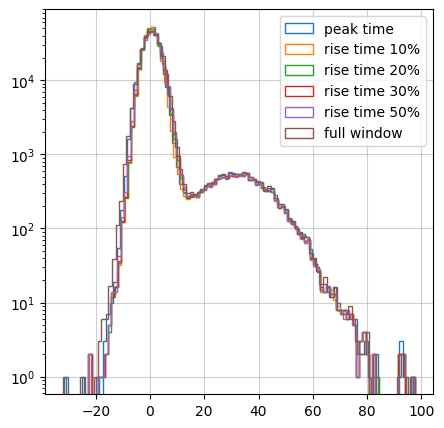

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

rg = None #(-20, 10)
den=False

axes.hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes.hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes.hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.legend();




# Fit pedestal only

In [10]:
df_sel.columns

print(np.min(df_sel.peak_amplitude_mV), np.max(df_sel.peak_amplitude_mV))


0.019348621368408203 6.845804691314697


In [26]:
ped_threshold_mV = 0.3
# pedestal_mask = ( df_sel.peak_amplitude_mV<=np.max(df_sel.peak_amplitude_mV)+1)
pedestal_mask = ( df_sel.peak_amplitude_mV<=ped_threshold_mV)
df_ped = df_sel[pedestal_mask].copy()
waveforms_ped = waveforms_sel[pedestal_mask.values]
print('pedestal selection efficiency: ', waveforms_ped.shape[0]/waveforms_sel.shape[0])

df_PEs = df_sel[~pedestal_mask].copy()
waveforms_PEs = waveforms_sel[~pedestal_mask.values]

pedestal selection efficiency:  0.947941036254053


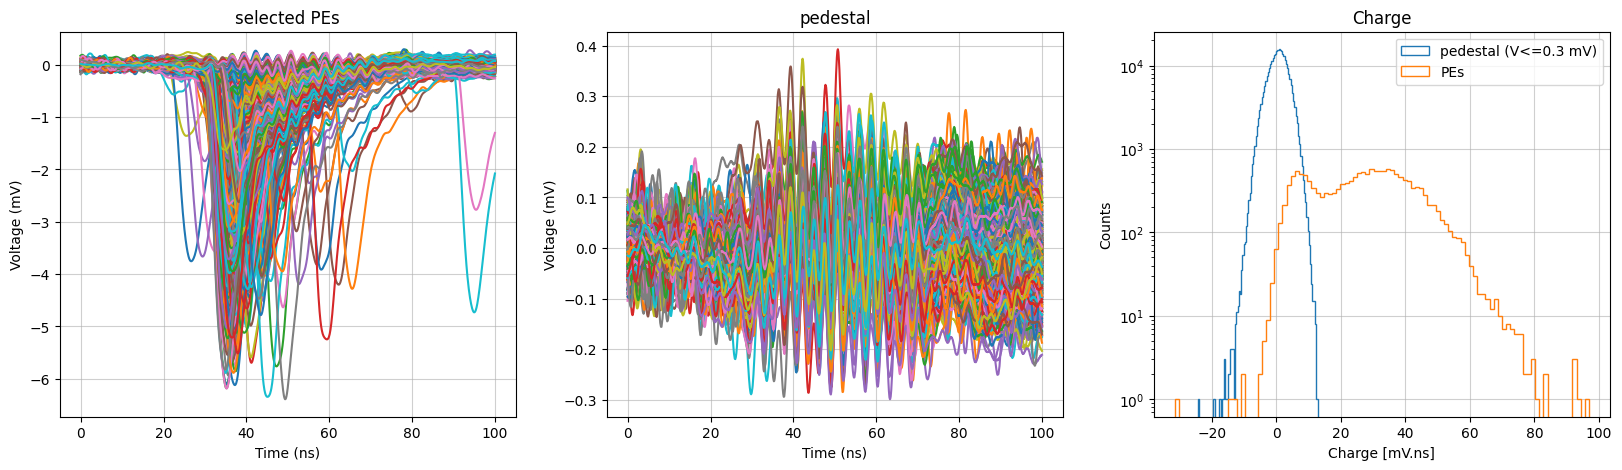

In [27]:
nEvts_plot = 1000
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes = axes.ravel()
add_plot_waveforms(axes[0], time_ns, waveforms_PEs[:nEvts_plot], title=f"selected PEs")
add_plot_waveforms(axes[1], time_ns, waveforms_ped[:nEvts_plot], title=f"pedestal")
axes[2].hist(df_ped.charge_peak_window_mV_ns,  bins=100, range=rg, histtype='step', label=f"pedestal (V<={ped_threshold_mV} mV)");
axes[2].hist(df_PEs.charge_peak_window_mV_ns,  bins=100, range=rg, histtype='step', label="PEs");
axes[2].set_title('Charge');
axes[2].set_xlabel('Charge [mV.ns]')
axes[2].set_ylabel('Counts')
axes[2].set_yscale('log')
axes[2].legend();

save_plot(fig, save_plots, save_dir, file_nickname, f"pedestal_selection",  Nevents=None);


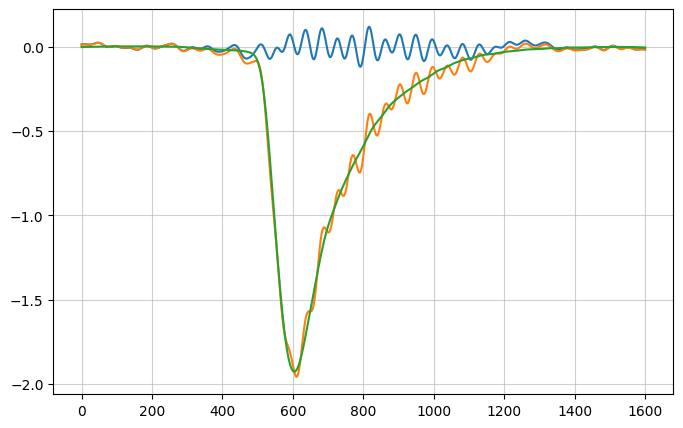

In [43]:
mean_ped = np.mean( waveforms_ped, axis=0)
mean_PEs = np.mean( waveforms_PEs, axis=0)

plt.plot(mean_ped)
plt.plot(mean_PEs)
plt.plot(mean_PEs - mean_ped)

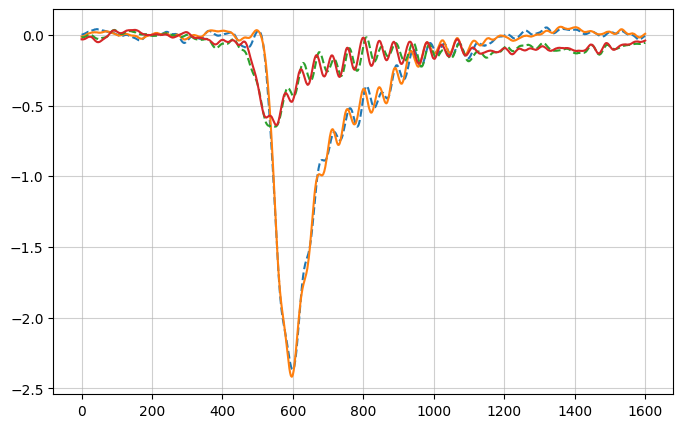

In [50]:
for i in range(2, 4):
    plt.plot(waveforms_PEs[i], linestyle='dashed')
    plt.plot(waveforms_PEs[i]-mean_ped)

In [28]:
charge_ped_mV_ns = df_ped.charge_cfd20_window_mV_ns.values
fit_ped_range = (np.min(charge_ped_mV_ns), np.max(charge_ped_mV_ns))
nbins = 250
print(f'fit range = ({fit_ped_range[0]:.2f}, {fit_ped_range[1]:.2f}); {nbins} bins')


# fit_ped_range = ( -16, 16 )


fit range = (-22.64, 14.20); 250 bins


### Gaussian

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         300248.0000 297967.5798     545.8667   [150124.0, 600496.0]   False
q0_mV_ns             0.3000      0.5636       0.0054           [-6.0, 10.0]   False
sigma0_mV_ns         2.5000      2.9220       0.0039            [0.0, 50.0]   False

[]


[]

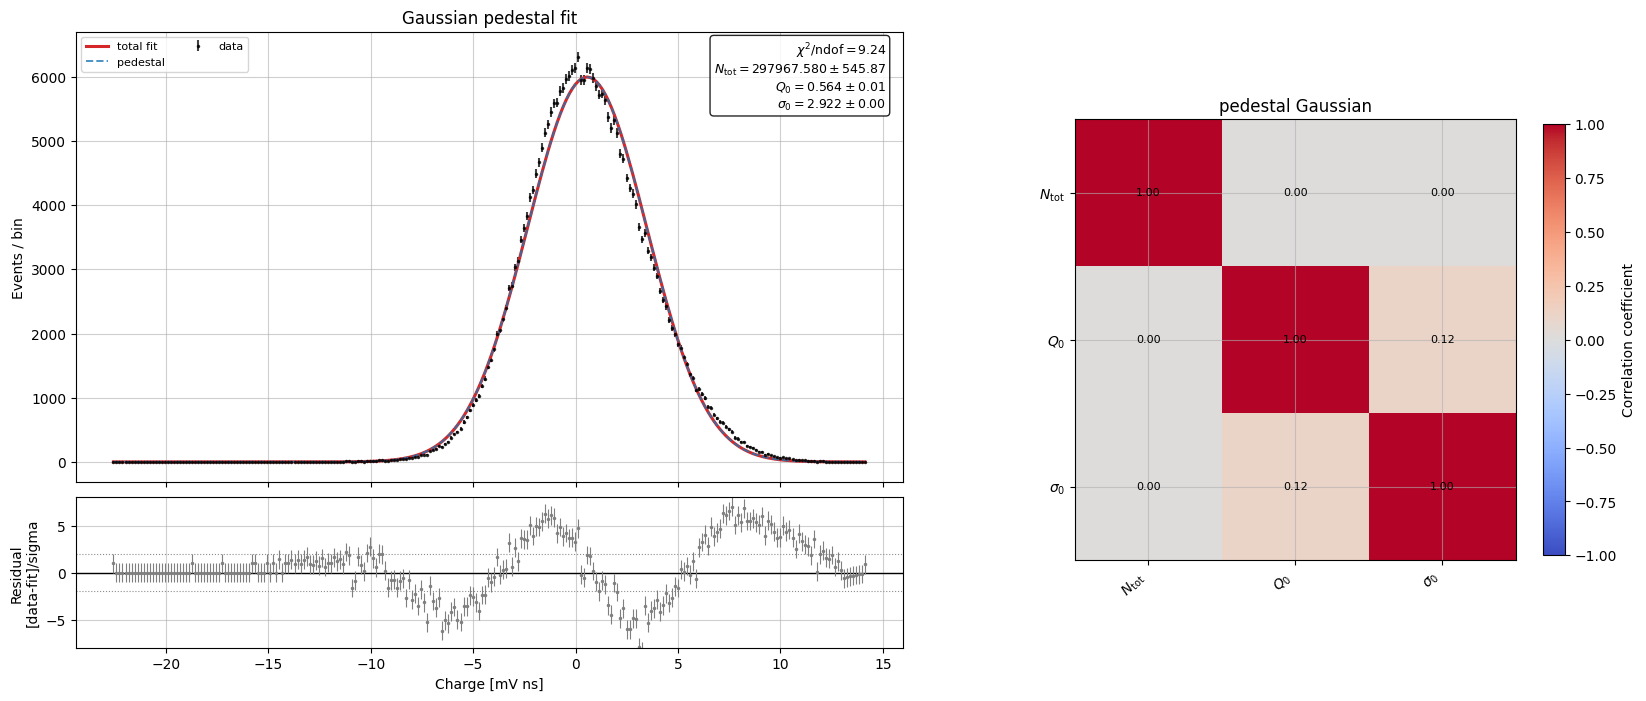

In [29]:
p0_pedestal = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # Set isFixed=True to hold a parameter at the initial value during the fit.
    "n_total":      [len(charge_ped_mV_ns), 0.5 * len(charge_ped_mV_ns), 2.0 * len(charge_ped_mV_ns), False],
    "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False]
}
fit_ped = fit_pedestal( charge_ped_mV_ns, p0=p0_pedestal, fit_range=fit_ped_range)
print_fit_result_table(fit_ped)
print()
print(fit_ped["diagnostics"])

fig, ax_fit, ax_resid, ax_corr = ( plot_fit_summary( fit_ped, title="Gaussian pedestal fit", shrink_colorbar=0.7, component_visibility_fraction=0, logscale=False))
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_pedestal_Gaussian_{nbins}bins",  Nevents=None)

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         300248.0000 299279.9420     550.9982   [150124.0, 600496.0]   False
q0_mV_ns             0.3000     -0.6805   49654.5442           [-6.0, 10.0]   False
sigma0_mV_ns         2.5000      2.6578       5.7517            [0.0, 50.0]   False
w                    0.0100      0.9998   39687.8702             [0.0, 1.0]   False
alpha                0.3000      0.7993       0.0082            [0.0, 10.0]   False

['w is close to the upper fit bound']


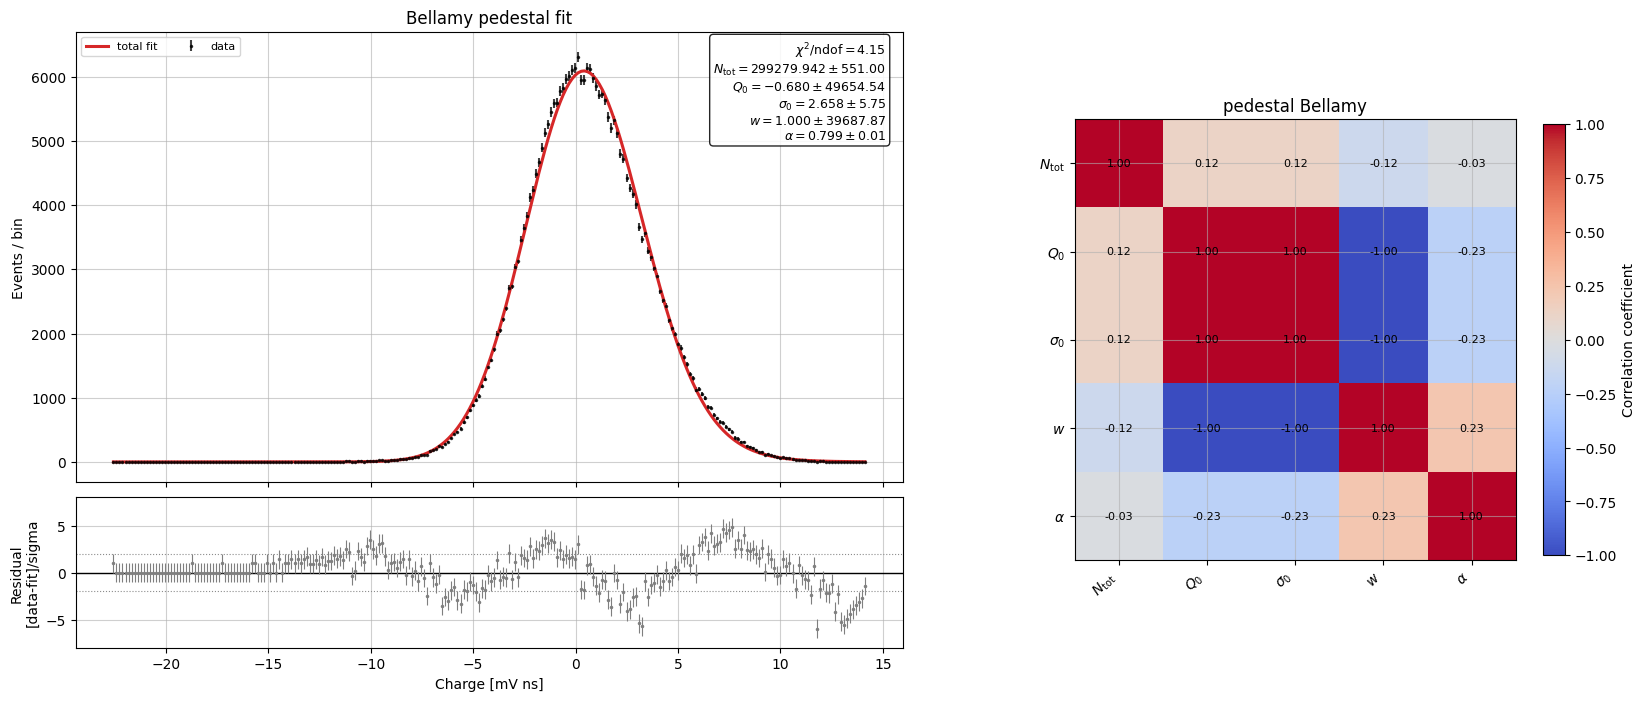

In [30]:
p0_pedestal_bel = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # Set isFixed=True to hold a parameter at the initial value during the fit.
    "n_total":      [len(charge_ped_mV_ns), 0.5 * len(charge_ped_mV_ns), 2.0 * len(charge_ped_mV_ns), False],
    "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
    "w":            [0.01, 0., 1.,     False], # probability that a measured signal is accompanied by a type-2 bkg process 
    "alpha":        [0.3, 0., 10.,     False], # coeff. of the exponential decay of type 2-background (positive)
}
fit_ped_bel = fit_pedestal_bellamy( charge_ped_mV_ns, p0=p0_pedestal_bel, fit_range=fit_ped_range)
print_fit_result_table(fit_ped_bel)
print()
print(fit_ped_bel["diagnostics"])

fig, ax_fit, ax_resid, ax_corr = ( plot_fit_summary( fit_ped_bel, title="Bellamy pedestal fit", shrink_colorbar=0.7, component_visibility_fraction=0, logscale=False))
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_pedestal_Bellamy_{nbins}bins",  Nevents=None);


### Bellamy (w fixed)

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         300248.0000 299279.9383     547.1129   [150124.0, 600496.0]   False
q0_mV_ns             0.3000     -0.6807       0.0135           [-6.0, 10.0]   False
sigma0_mV_ns         2.5000      2.6579       0.0065            [0.0, 50.0]   False
w                    1.0000      1.0000       0.0000             [1.0, 1.0]    True
alpha                0.3000      0.7993       0.0080            [0.0, 10.0]   False

[]


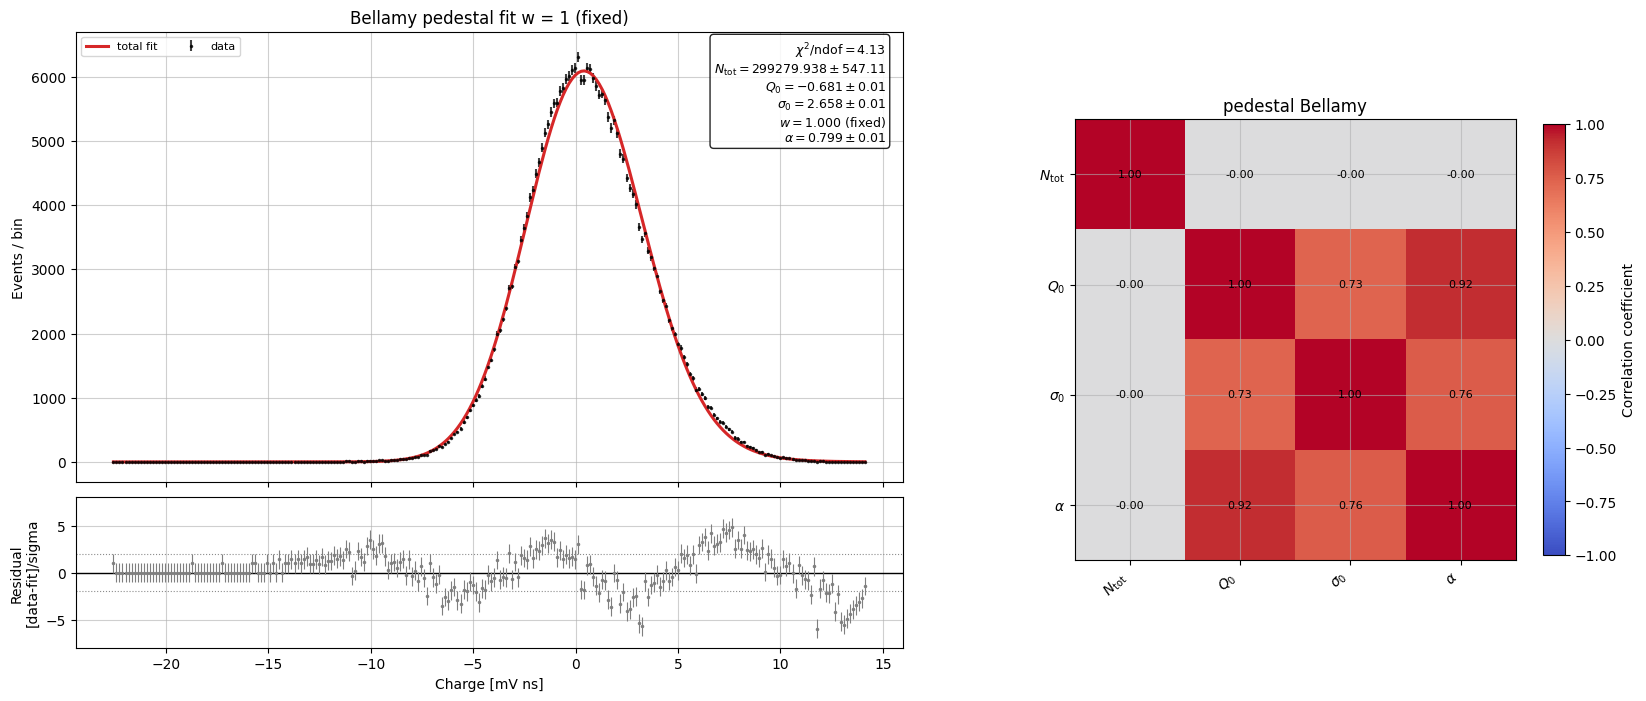

In [31]:

w_fixed = 1
p0_pedestal_bel = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    "n_total":      [len(charge_ped_mV_ns), 0.5 * len(charge_ped_mV_ns), 2.0 * len(charge_ped_mV_ns), False],
    "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
    "w":            [w_fixed, 0., 1.,      True], # probability that a measured signal is accompanied by a type-2 bkg process 
    "alpha":        [0.3, 0., 10.,     False], # coeff. of the exponential decay of type 2-background (positive)
}
fit_ped_bel = fit_pedestal_bellamy( charge_ped_mV_ns, p0=p0_pedestal_bel, fit_range=fit_ped_range)
print_fit_result_table(fit_ped_bel)
print()
print(fit_ped_bel["diagnostics"])

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_ped_bel, title=f"Bellamy pedestal fit w = {w_fixed} (fixed)", shrink_colorbar=0.7, component_visibility_fraction=0, logscale=False)
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_pedestal_Bellamy_{nbins}bins_w{w_fixed}",  Nevents=None);

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         300248.0000 299273.9759     547.1075   [150124.0, 600496.0]   False
q0_mV_ns             0.3000     -0.4316       0.0113           [-6.0, 10.0]   False
sigma0_mV_ns         2.5000      2.6690       0.0063            [0.0, 50.0]   False
w                    0.8000      0.8000       0.0000             [0.8, 0.8]    True
alpha                0.3000      0.7985       0.0080            [0.0, 10.0]   False

[]


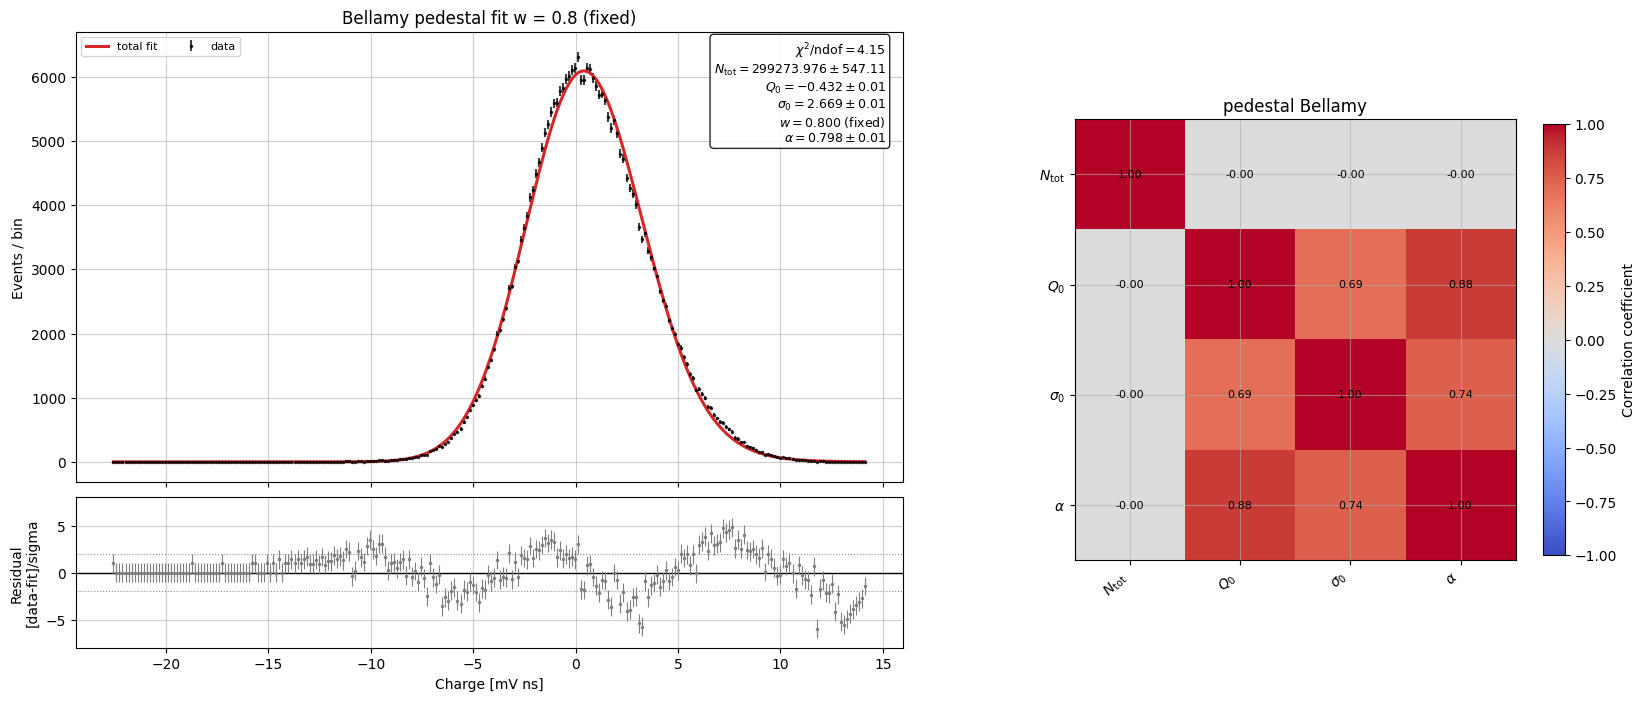

In [32]:
w_fixed = 0.8
p0_pedestal_bel = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    "n_total":      [len(charge_ped_mV_ns), 0.5 * len(charge_ped_mV_ns), 2.0 * len(charge_ped_mV_ns), False],
    "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
    "w":            [w_fixed, 0., 1.,      True], # probability that a measured signal is accompanied by a type-2 bkg process 
    "alpha":        [0.3, 0., 10.,     False], # coeff. of the exponential decay of type 2-background (positive)
}
fit_ped_bel = fit_pedestal_bellamy( charge_ped_mV_ns, p0=p0_pedestal_bel, fit_range=fit_ped_range)
print_fit_result_table(fit_ped_bel)
print()
print(fit_ped_bel["diagnostics"])

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_ped_bel, title=f"Bellamy pedestal fit w = {w_fixed} (fixed)", shrink_colorbar=0.7, component_visibility_fraction=0, logscale=False)
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_pedestal_Bellamy_{nbins}bins_w{w_fixed}",  Nevents=None);

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         300248.0000 299188.1229     547.0304   [150124.0, 600496.0]   False
q0_mV_ns             0.3000     -0.0687       0.0085           [-6.0, 10.0]   False
sigma0_mV_ns         2.5000      2.7210       0.0056            [0.0, 50.0]   False
w                    0.5000      0.5000       0.0000             [0.5, 0.5]    True
alpha                0.3000      0.7837       0.0083            [0.0, 10.0]   False

[]


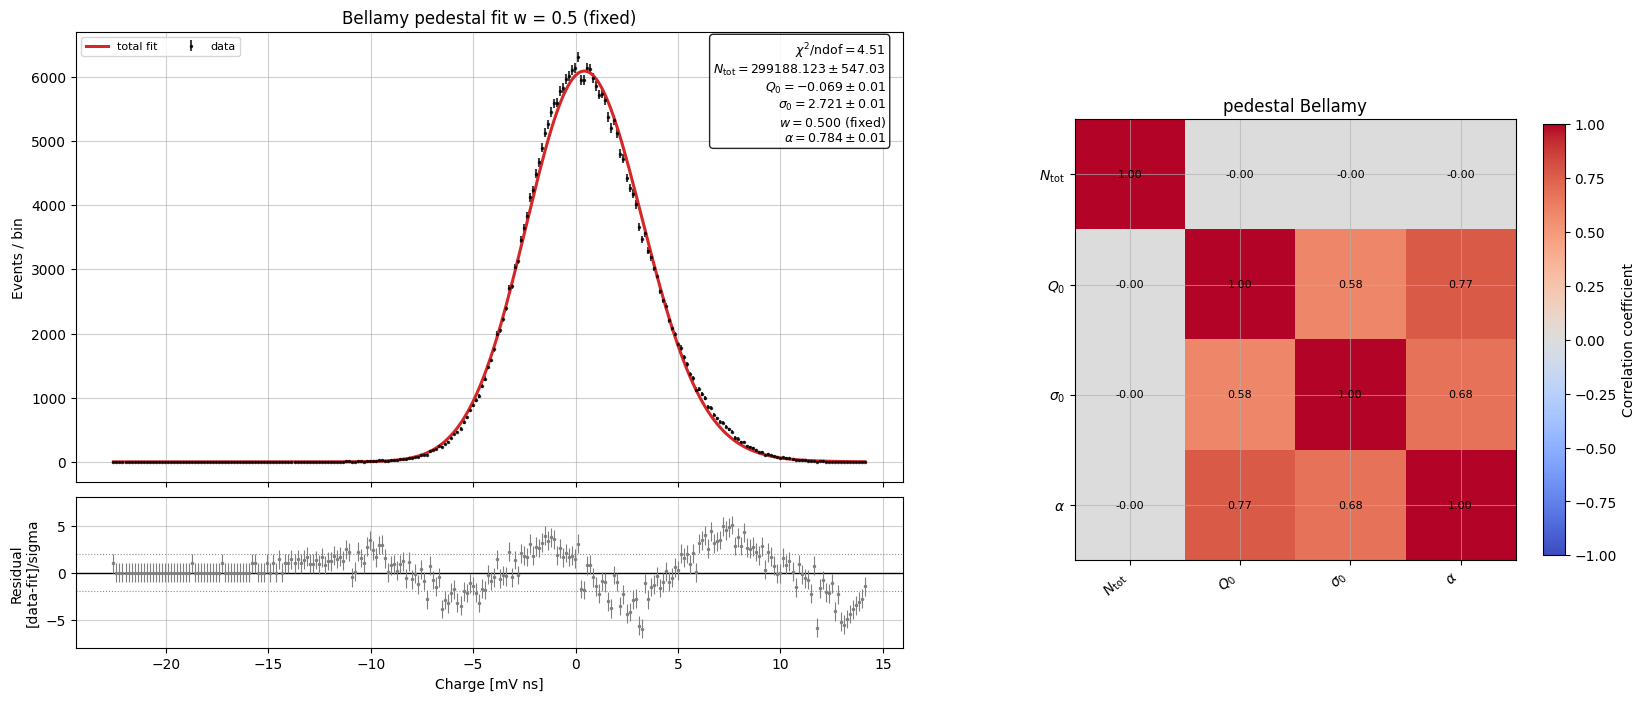

In [33]:
w_fixed = 0.5
p0_pedestal_bel = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    "n_total":      [len(charge_ped_mV_ns), 0.5 * len(charge_ped_mV_ns), 2.0 * len(charge_ped_mV_ns), False],
    "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
    "w":            [w_fixed, 0., 1.,      True], # probability that a measured signal is accompanied by a type-2 bkg process 
    "alpha":        [0.3, 0., 10.,     False], # coeff. of the exponential decay of type 2-background (positive)
}
fit_ped_bel = fit_pedestal_bellamy( charge_ped_mV_ns, p0=p0_pedestal_bel, fit_range=fit_ped_range)
print_fit_result_table(fit_ped_bel)
print()
print(fit_ped_bel["diagnostics"])

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_ped_bel, title=f"Bellamy pedestal fit w = {w_fixed} (fixed)", shrink_colorbar=0.7, component_visibility_fraction=0, logscale=False)
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_pedestal_Bellamy_{nbins}bins_w{w_fixed}",  Nevents=None);

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         300248.0000 298210.3580     546.1875   [150124.0, 600496.0]   False
q0_mV_ns             0.3000      0.5397       0.0054           [-6.0, 10.0]   False
sigma0_mV_ns         2.5000      2.9064       0.0040            [0.0, 50.0]   False
w                    0.0100      0.0100       0.0000             [0.0, 0.0]    True
alpha                0.3000      0.3721       0.0165            [0.0, 10.0]   False

[]


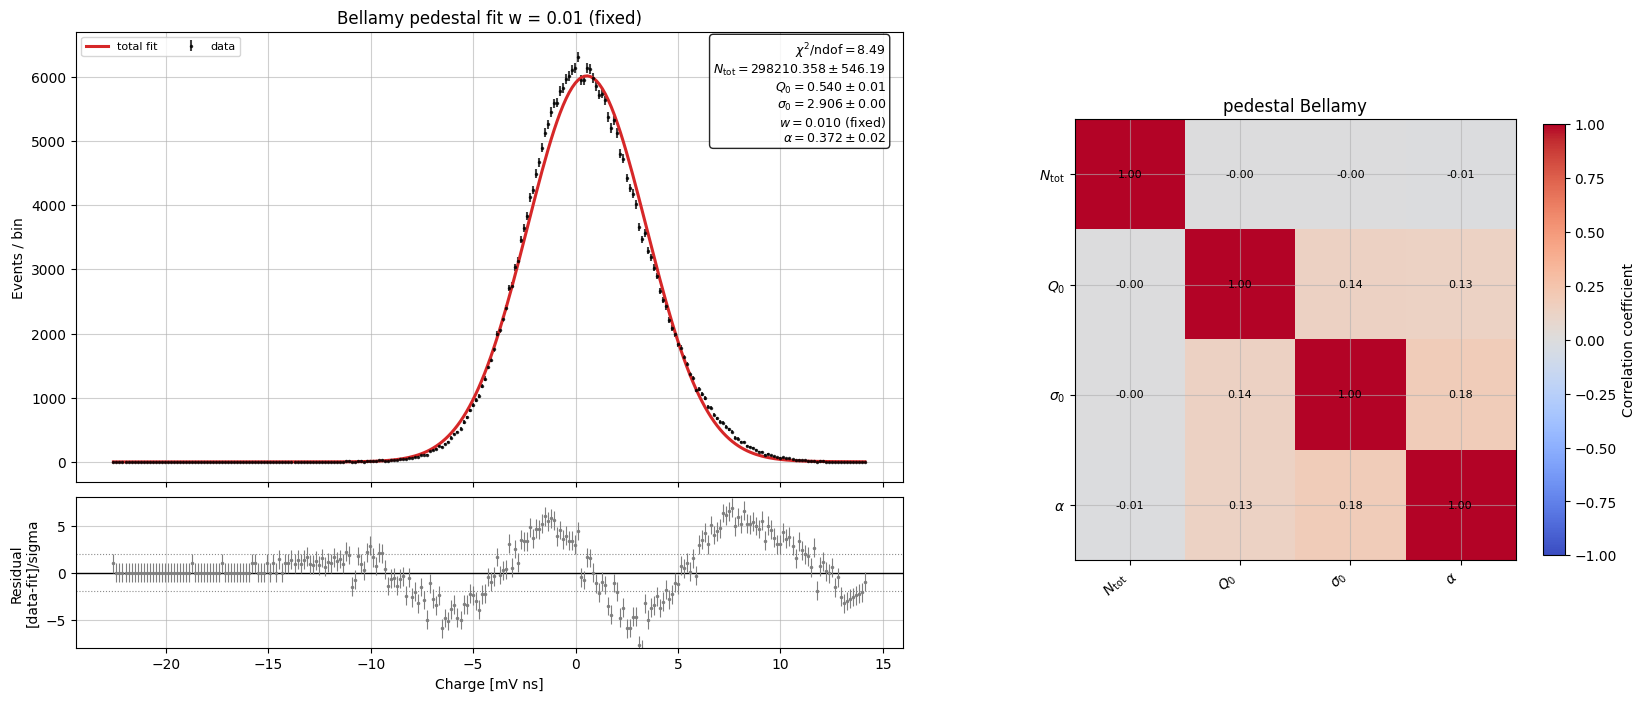

In [34]:
w_fixed = 0.01
p0_pedestal_bel = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    "n_total":      [len(charge_ped_mV_ns), 0.5 * len(charge_ped_mV_ns), 2.0 * len(charge_ped_mV_ns), False],
    "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
    "w":            [w_fixed, 0., 1.,      True], # probability that a measured signal is accompanied by a type-2 bkg process 
    "alpha":        [0.3, 0., 10.,     False], # coeff. of the exponential decay of type 2-background (positive)
}
fit_ped_bel = fit_pedestal_bellamy( charge_ped_mV_ns, p0=p0_pedestal_bel, fit_range=fit_ped_range)
print_fit_result_table(fit_ped_bel)
print()
print(fit_ped_bel["diagnostics"])

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_ped_bel, title=f"Bellamy pedestal fit w = {w_fixed} (fixed)", shrink_colorbar=0.7, component_visibility_fraction=0, logscale=False)
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_pedestal_Bellamy_{nbins}bins_w{w_fixed}",  Nevents=None);

### Exp.Gaussian

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         300248.0000 299279.9383     547.1129   [150124.0, 600496.0]   False
q0_mV_ns             0.3000     -0.6807       0.0135           [-6.0, 10.0]   False
sigma0_mV_ns         2.5000      2.6579       0.0065            [0.0, 50.0]   False
alpha                0.3000      0.7993       0.0080            [0.0, 10.0]   False

[]


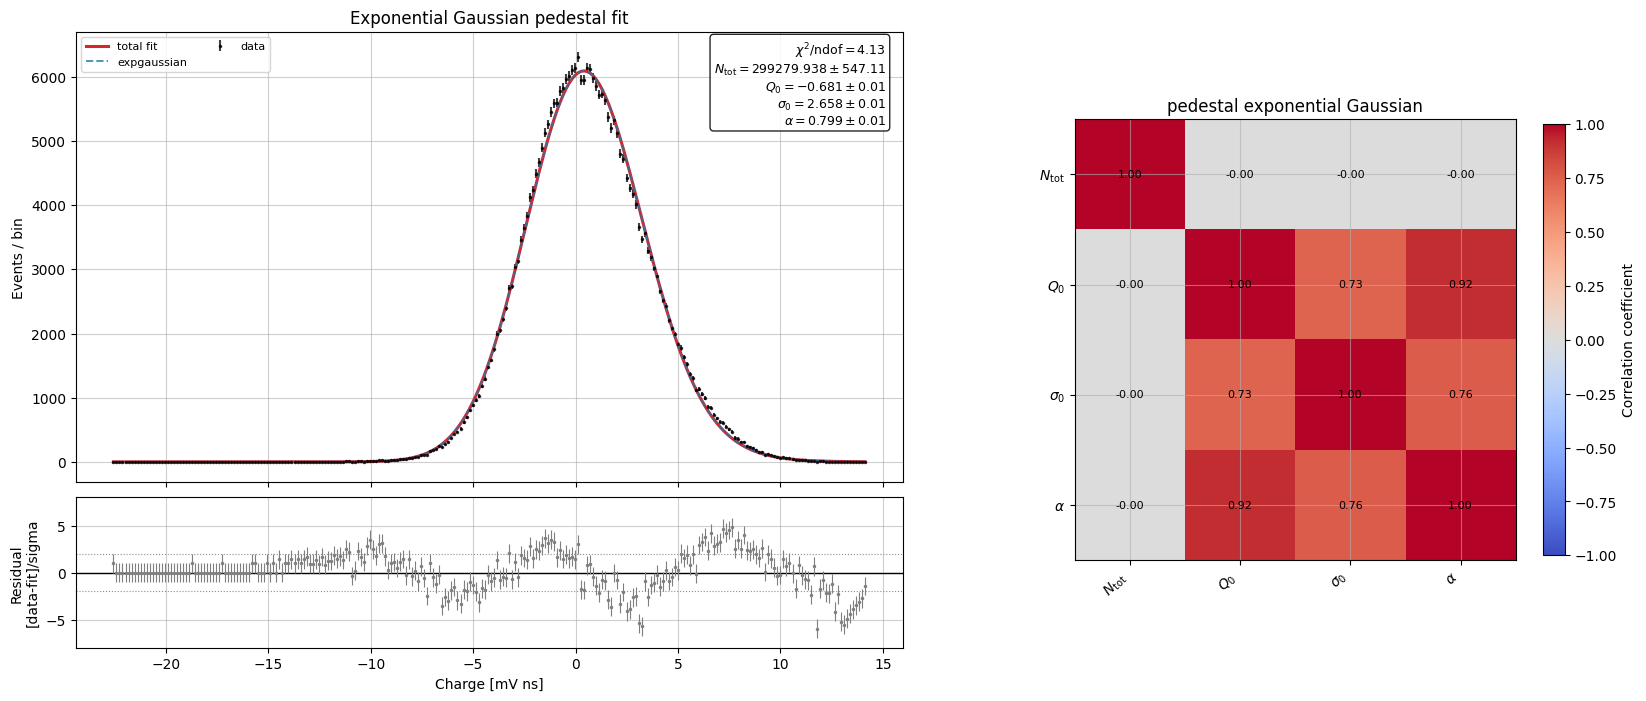

In [35]:
p0_pedestal_expgauss = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    "n_total":      [len(charge_ped_mV_ns), 0.5 * len(charge_ped_mV_ns), 2.0 * len(charge_ped_mV_ns), False],
    "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
    "alpha":        [0.3, 0., 10.,     False], # coeff. of the exponential decay of type 2-background (positive)
}
fit_ped_expgauss = fit_pedestal_expgauss( charge_ped_mV_ns, p0=p0_pedestal_expgauss, fit_range=fit_ped_range)
print_fit_result_table(fit_ped_expgauss)
print()
print(fit_ped_expgauss["diagnostics"])

fig, ax_fit, ax_resid, ax_corr = ( plot_fit_summary( fit_ped_expgauss, title="Exponential Gaussian pedestal fit", shrink_colorbar=0.7, component_visibility_fraction=0, logscale=False))
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_pedestal_exGauss_{nbins}bins",  Nevents=None);

# Fits to all files

In [21]:
data_dir = Path("data/WA0089/LED_sweep/260615")
chunk_size = 512 
ped_threshold_mV = 0.5
nbins = 250

max_files = None

In [23]:
file_names = [f"WA0089_850V_20MHz_Cold_led{i}" for i in [0, 1, 2, 3, 4]]

results = {
    "Gaussian": [],
    "Bellamy": [],
    "ExGauss": [],
}

for file_name in file_names:
    print(file_name)
    files = find_pmt_files(data_dir, file_name, max_files=max_files)
    print(f" Number of files loaded: {len(files)}")

    cfg = load_config("config_default.yml", file_name)
    baseline_window_width_ns          = cfg.general.baseline_window_width_ns
    selection_peak_threshold_max_mV   = cfg.general.global_peak_voltage_max_mV

    # find time boundaries
    max_sample_events = 1
    sample = read_waveform_sample(files, max_events=max_sample_events)
    time_ns = sample["time_ns"]
    adc_step_mV = sample["adc_step_mV"]
    print(f" Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns, Sampling: {np.median(np.diff(time_ns)):.5f} ns, ADC step: {adc_step_mV:.6f} mV")
    baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + baseline_window_width_ns))

    prerocessed_data = load_preprocessed_waveforms(
        files,
        chunk_size=chunk_size,
        remove_saturation=True,
        baseline_subtraction=True,
        baseline_window_ns=baseline_window_ns,
        low_limit_mV=None,
        high_limit_mV=None,
        margin_mV=0.0,
        max_saturated_samples=0
    )
    time_ns = prerocessed_data["time_ns"]
    voltage_mV = prerocessed_data["voltage_mV"]
    print(f"Preprocessed sample: {prerocessed_data["voltage_mV"].shape}")
    print(f"Efficiency of saturation cut: {prerocessed_data['saturation_summary']['efficiency']*100:.3f} %")
    remove = ['is_saturated', 'n_saturated_samples']
    preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in remove}

    df =  build_waveform_feature_dataframe( time_ns, voltage_mV, extra=preprocessed_event_info)

    sanity_mask_reject = ( df.peak_time_ns.between( baseline_window_ns[0], baseline_window_ns[1] ) & (df.peak_amplitude_mV >= 0.5) )
    sanity_mask_keep = ~sanity_mask_reject
    df_sel = df[sanity_mask_keep].copy()
    waveforms_sel = voltage_mV[df_sel["event_id"].values]
    
    pedestal_mask = ( df_sel.peak_amplitude_mV<=ped_threshold_mV)
    df_ped = df_sel[pedestal_mask].copy()
    waveforms_ped = waveforms_sel[pedestal_mask.values]
    print('pedestal selection efficiency: ', waveforms_ped.shape[0]/waveforms_sel.shape[0])
    df_PEs = df_sel[~pedestal_mask].copy()
    waveforms_PEs = waveforms_sel[~pedestal_mask.values]

    charge_ped_mV_ns = df_ped.charge_cfd20_window_mV_ns.values
    fit_ped_range = (np.min(charge_ped_mV_ns), np.max(charge_ped_mV_ns))
    print(f'fit range = ({fit_ped_range[0]:.2f}, {fit_ped_range[1]:.2f}); {nbins} bins')

    # Gaussian
    p0_pedestal = {
        "n_total":      [len(charge_ped_mV_ns), 0.5 * len(charge_ped_mV_ns), 2.0 * len(charge_ped_mV_ns), False],
        "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
        "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False]
    }
    fit_ped_gauss = fit_pedestal( charge_ped_mV_ns, p0=p0_pedestal, fit_range=fit_ped_range)
    results["Gaussian"].append(fit_ped_gauss)

    # Bellmays
    p0_pedestal_bel = {
        "n_total":      [len(charge_ped_mV_ns), 0.5 * len(charge_ped_mV_ns), 2.0 * len(charge_ped_mV_ns), False],
        "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
        "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
        "w":            [0.01, 0., 1.,     False], # probability that a measured signal is accompanied by a type-2 bkg process 
        "alpha":        [0.3, 0., 10.,     False], # coeff. of the exponential decay of type 2-background (positive)
    }
    fit_ped_bel = fit_pedestal_bellamy( charge_ped_mV_ns, p0=p0_pedestal_bel, fit_range=fit_ped_range)
    results["Bellamy"].append(fit_ped_bel)

    # ExGauss
    p0_pedestal_expgauss = {
        "n_total":      [len(charge_ped_mV_ns), 0.5 * len(charge_ped_mV_ns), 2.0 * len(charge_ped_mV_ns), False],
        "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
        "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
        "alpha":        [0.3, 0., 10.,     False], # coeff. of the exponential decay of type 2-background (positive)
    }
    fit_ped_expgauss = fit_pedestal_expgauss( charge_ped_mV_ns, p0=p0_pedestal_expgauss, fit_range=fit_ped_range)
    results["ExGauss"].append(fit_ped_expgauss)

    print()

WA0089_850V_20MHz_Cold_led0
 Number of files loaded: 1
 Time range: 0.013 to 100.013 ns, Sampling: 0.06250 ns, ADC step: 0.000214 mV
Preprocessed sample: (31682, 1601)
Efficiency of saturation cut: 100.000 %


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a prominence of 0
  widths, width_heights, left_ips, right_ips = peak_widths(
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a width of 0
  widths, width_heights, left_ips, right_ips = peak_widths(


pedestal selection efficiency:  0.9883842050440327
fit range = (-14.21, 16.34); 250 bins

WA0089_850V_20MHz_Cold_led1
 Number of files loaded: 10
 Time range: -0.029 to 99.971 ns, Sampling: 0.06250 ns, ADC step: 0.000214 mV
Preprocessed sample: (316767, 1601)
Efficiency of saturation cut: 99.983 %
pedestal selection efficiency:  0.955319397481191
fit range = (-22.64, 17.40); 250 bins

WA0089_850V_20MHz_Cold_led2
 Number of files loaded: 5
 Time range: -0.030 to 99.970 ns, Sampling: 0.06250 ns, ADC step: 0.000214 mV
Preprocessed sample: (157891, 1601)
Efficiency of saturation cut: 99.672 %
pedestal selection efficiency:  0.8267052652916435
fit range = (-24.67, 22.51); 250 bins

WA0089_850V_20MHz_Cold_led3
 Number of files loaded: 5
 Time range: -0.035 to 99.965 ns, Sampling: 0.06250 ns, ADC step: 0.000638 mV
Preprocessed sample: (158400, 1601)
Efficiency of saturation cut: 99.994 %
pedestal selection efficiency:  0.3589351787540884
fit range = (-17.16, 16.06); 250 bins

WA0089_850V_20MH

In [32]:

def chi2_ndof(results, model_name, indices):
    return [ results[model_name][i]["chi2"] / results[model_name][i]["ndof"] for i in indices]

def pars(results, model_name, indices, parname):
    return [ results[model_name][i]["parameters"][parname] for i in indices]

def errs(results, model_name, indices, parname):
    return [ results[model_name][i]["errors"][parname] for i in indices]

led_rg = np.arange(0, 4)

chi2_ndof_gauss = chi2_ndof(results, "Gaussian", led_rg)
chi2_ndof_Bel  = chi2_ndof(results, "Bellamy", led_rg)
chi2_ndof_ExG  = chi2_ndof(results, "ExGauss", led_rg)

Q0_gauss = pars(results, "Gaussian", led_rg, "q0_mV_ns")
Q0_Bel   = pars(results, "Bellamy", led_rg, "q0_mV_ns")
Q0_ExG   = pars(results, "ExGauss", led_rg, "q0_mV_ns")

Q0_gauss_err = errs(results, "Gaussian", led_rg, "q0_mV_ns")
Q0_Bel_err   = errs(results, "Bellamy", led_rg, "q0_mV_ns")
Q0_ExG_err   = errs(results, "ExGauss", led_rg, "q0_mV_ns")

s0_gauss = pars(results, "Gaussian", led_rg, "sigma0_mV_ns")
s0_Bel   = pars(results, "Bellamy", led_rg, "sigma0_mV_ns")
s0_ExG   = pars(results, "ExGauss", led_rg, "sigma0_mV_ns")

s0_gauss_err = errs(results, "Gaussian", led_rg, "sigma0_mV_ns")
s0_Bel_err   = errs(results, "Bellamy", led_rg, "sigma0_mV_ns")
s0_ExG_err   = errs(results, "ExGauss", led_rg, "sigma0_mV_ns")




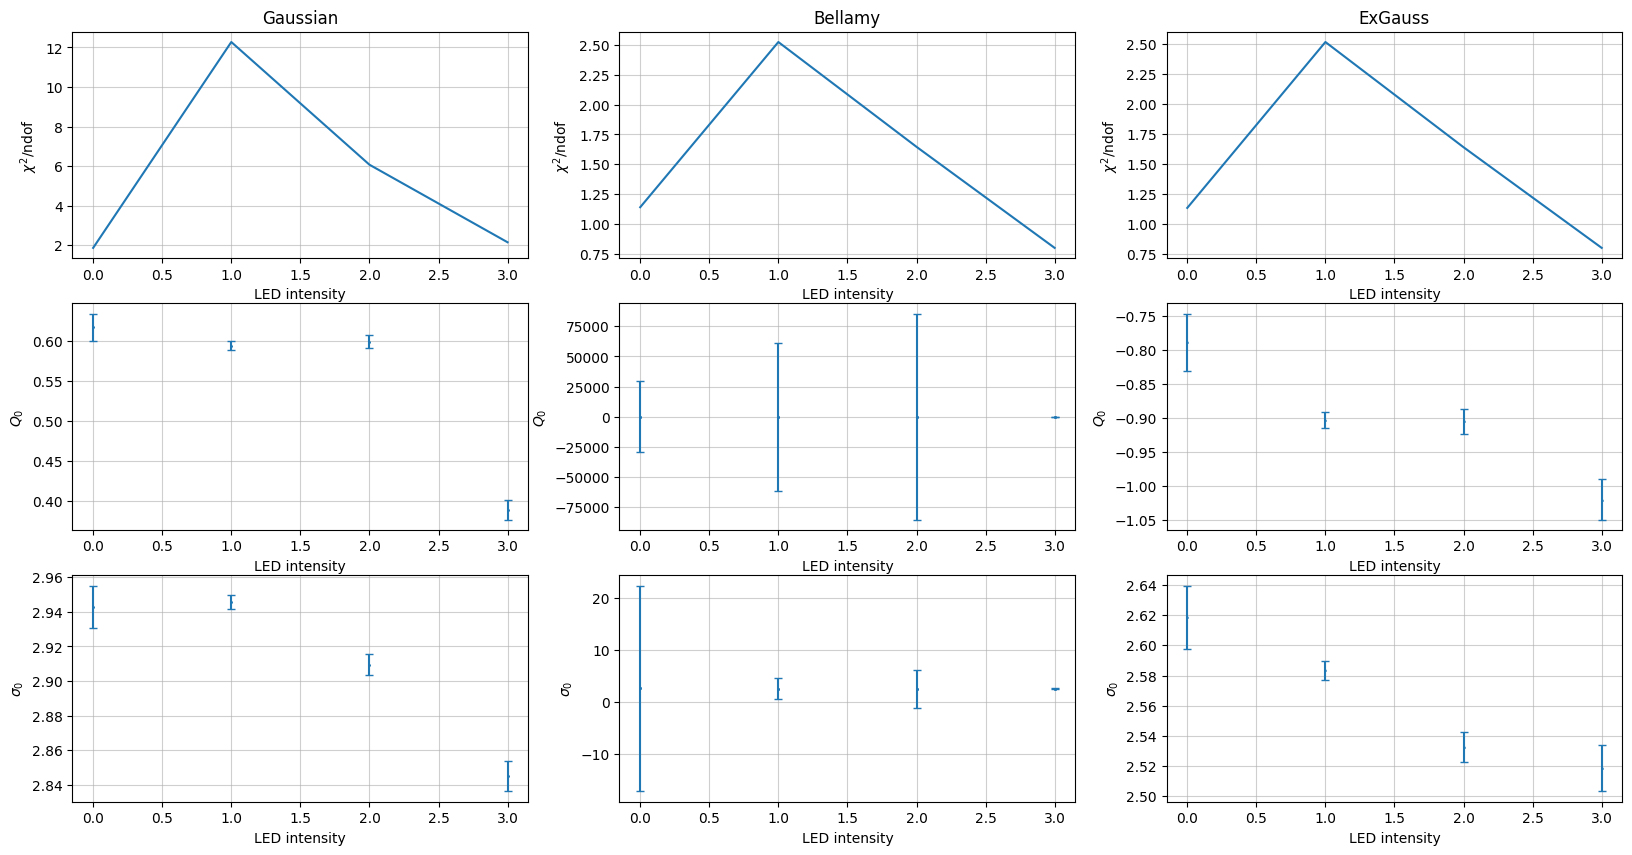

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(20, 10))
axes = axes.ravel()

axes[0].plot(led_rg, chi2_ndof_gauss);
axes[0].set_title('Gaussian');
axes[1].plot(led_rg, chi2_ndof_Bel);
axes[1].set_title('Bellamy');
axes[2].plot(led_rg, chi2_ndof_ExG);
axes[2].set_title('ExGauss');

axes[3].errorbar(led_rg, Q0_gauss, yerr=Q0_gauss_err, fmt="o", capsize=3, markersize=1.1);
axes[4].errorbar(led_rg, Q0_Bel,   yerr=Q0_Bel_err, fmt="s", capsize=3, markersize=1.1);
axes[5].errorbar(led_rg, Q0_ExG,   yerr=Q0_ExG_err, fmt="^", capsize=3, markersize=1.1);

axes[6].errorbar(led_rg, s0_gauss, yerr=s0_gauss_err, fmt="o", capsize=3, markersize=1.1);
axes[7].errorbar(led_rg, s0_Bel,   yerr=s0_Bel_err, fmt="s", capsize=3, markersize=1.1);
axes[8].errorbar(led_rg, s0_ExG,   yerr=s0_ExG_err, fmt="^", capsize=3, markersize=1.1);

for i in range(0, 3):
    axes[i].set_xlabel('LED intensity')
    axes[i].set_ylabel(rf"$\chi^2/\mathrm{{ndof}}$")

## get the errors as well
for i in range(3, 6):
    axes[i].set_xlabel('LED intensity')
    axes[i].set_ylabel(rf"$Q_0$")

for i in range(6, 9):
    axes[i].set_xlabel('LED intensity')
    axes[i].set_ylabel(rf"$\sigma_0$")

save_plot(fig, save_plots, save_dir, file_nickname, f"fit_all_intensities_1file_0-3",  Nevents=None);